In [15]:
import numpy as np  # generic math functions
import scipy.linalg as spla
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


SMALL_SIZE = 20
MEDIUM_SIZE = 24
BIGGER_SIZE = 26
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=SMALL_SIZE)

plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the Xtick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the Ytick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # fontsize of the legend 
plt.rc('figure', titlesize=SMALL_SIZE)  # fontsize of the figure title
fmm=['x', 'o', 's', '+', 'p', 'd', '1']
colorband=['mediumblue', 'darkcyan', 'orange', 'deeppink', 'darkmagenta', 'darkred']
markerband = ['o', 'v', '^', 'D', 's', 'h']

# Load and see the data

### put the proper path to the data after downloading

In [16]:
delta_arr = np.round(np.arange(0.2106, 0.225, 0.0006),4) ## 24 points
L_arr =np.array([96, 128, 192, 256, 384])

# For storing
sxy=np.zeros((len(L_arr), len(delta_arr)))
sxy_err=np.zeros((len(L_arr), len(delta_arr)))

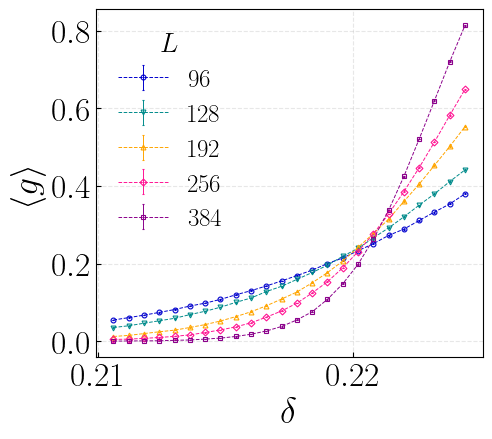

In [17]:
plt.gca().set_box_aspect(0.9)

markerband = ['o', 'v', '^', 'D', 's', 'h']
colorband=['mediumblue', 'darkcyan', 'orange', 'deeppink', 'darkmagenta', 'darkred']

for il, L in enumerate(L_arr):

    data=np.loadtxt('/Users/nabaprakash/Downloads/data_fit/sigmaxy_L'+str(L)+'.txt')
    
    sxy[il] = data[:, 1]
    sxy_err[il] = data[:, 2]
    
    plt.errorbar((data[:,0]), data[:,1], yerr=data[:,2], marker=markerband[il], markersize=3.5, 
                 color=colorband[il], mew=0.8, mfc='none', linestyle="--", 
        capsize=1, capthick = .4, linewidth=0.7, label=L,)


plt.xlabel(r"$\delta$")
plt.ylabel(r"$\langle g \rangle$")
#plt.xticks([0.825, 0.85, 0.875, 0.9])
plt.legend(title="$L$", fontsize=18, loc = "upper left", frameon = False)
plt.tick_params(direction='in')
plt.grid(True, linestyle="--", alpha=0.3)
#plt.axvline(-0.294)
plt.tight_layout()
plt.show()
#plt.savefig("AI_CI_raw_p0p4.pdf")

<span style="color:red"> Notice how the crossing point above between diffent curves keep shifting</span>

# Step 1: put all $L$'s and all $\delta$'s into one long list

In [18]:
# This is for using only a part of the data (to trim the data)
ap=5
pi=2


delta_arr = delta_arr[ap:-pi]


L_arr_all = np.kron(L_arr, np.ones(len(delta_arr)))
delta_arr_all = np.kron(np.ones(L_arr.size),delta_arr)

In [19]:
xData=np.array([L_arr_all, delta_arr_all])

yData1=sxy[:,ap:-pi]
errE1=sxy_err[:, ap:-pi]

# just an reshape
yData=sxy[:,ap:-pi].flatten()
errE=sxy_err[:, ap:-pi].flatten()

### let's see if we have combined them correctly

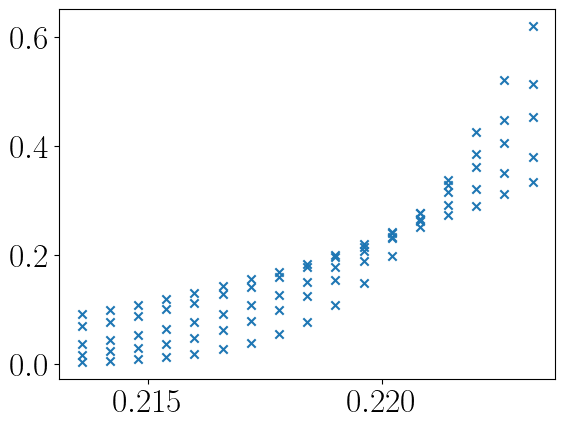

In [20]:
plt.scatter(xData[1,:],yData,marker = "x")

# Step 2: write down the formula we think the data follows.

In [30]:
def cfit(x, *aa):

    larr=x[0]
    marr=x[1]
    
    a0 = aa[0]
    a1 = aa[1]
    a2 = aa[2]
    a3 = aa[3]
    # 
    
    b0 = aa[4]
    b1 = aa[5]

    b2 = aa[8]
    b3 = aa[9]

    
    mc = aa[6]
    nu = aa[7]
    # y  = aa[8]  ##<--- fixed it by hand close to 1. 
    
    mred = (marr-mc)/mc

    xx = larr**(1/nu) * mred

    return a0 + a1*xx  + a2*xx**2  +  a3*xx**3 + b0*larr**(-0.7) * (1 +  b1*xx +  b2*xx**2  +  b3*xx**3  )

# Step 3: let curve_fit find the best parameters.

## what we are plotting here is the corrected data (see the curves crossing at one point !!)

[ 0.41662685  0.24381836  0.04966475  0.0035927  -3.39594195  0.57674998
  0.22163608  1.19624318  0.11374764  0.00996588]


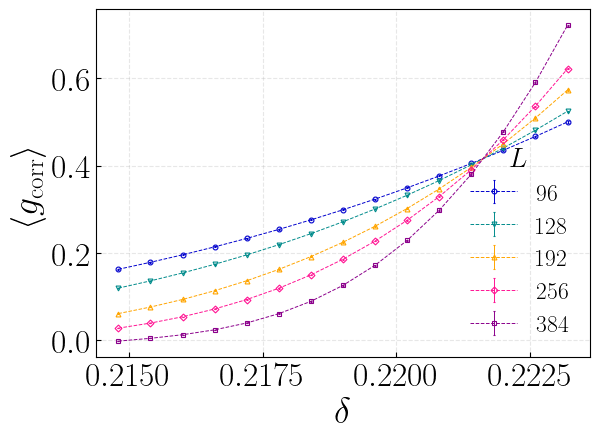

In [31]:
popt, pcov = curve_fit(cfit, xData, yData, sigma=errE, maxfev=int(1e5), absolute_sigma=True, p0=[1, 1, 1, 0.1, 1.12, 0.22, 0.221, 1,1,1])

lent = 17

popt1 = popt.copy()
popt1[0:4] = 0


corrected_data = cfit(xData, *popt) - cfit(xData, *popt1) 

for il, L in enumerate(L_arr):

    plt.errorbar(delta_arr[2:], (corrected_data[il*lent:(il*lent)+lent])[2:], yerr=errE1[il][2:], marker=markerband[il], 
                 markersize=3.5, color=colorband[il], mew=0.8, mfc='none', linestyle="--", 
        capsize=1, capthick = .4, linewidth=0.7, label=L)
    
    
plt.xlabel(r"$\delta$")
plt.ylabel(r"$\langle g_{\mathrm{corr}} \rangle$")
#plt.xticks([0.825, 0.85, 0.875, 0.9])
plt.legend(title="$L$", fontsize=17,  loc = "lower right",frameon = False)
plt.tick_params(direction='in')
plt.grid(True, linestyle="--", alpha=0.3)
#plt.axvline(-0.294)
plt.tight_layout()



print(popt)


plt.show()

<span style="color:red"> Remember: to get the correct exponent requires further inspections, and consistency ! (see notes for details) </span>

# Get the collapse

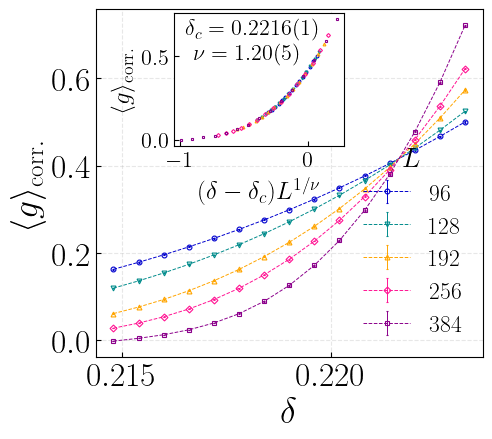

In [34]:
Ll=np.array([64, 96, 128, 192, 256, 384])
plt.gca().set_box_aspect(0.9)

for il, L in enumerate(L_arr):

    plt.errorbar(delta_arr[2:], (corrected_data[il*lent:(il*lent)+lent])[2:], yerr=errE1[il][2:], marker=markerband[il], 
                 markersize=3.5, color=colorband[il], mew=0.8, mfc='none', linestyle="--", 
        capsize=1, capthick = .4, linewidth=0.7, label=L)
    
    
plt.xlabel(r"$\delta$")
plt.ylabel(r"$\langle g \rangle_{\rm{corr.}} $")
#plt.xticks([0.825, 0.85, 0.875, 0.9])
plt.legend(title="$L$", fontsize=17,  loc = "lower right",frameon = False)
plt.tick_params(direction='in')
plt.grid(True, linestyle="--", alpha=0.3)
#plt.axvline(-0.294)
plt.tight_layout()


# ---------- INSET PLOT: scaling collapse (no error bars) ----------
ax_inset = inset_axes(plt.gca(), width="52%", height="45%", loc="upper left",bbox_to_anchor=(0.2, 0.14, 0.85, 0.85), 
                      borderpad=0.01, bbox_transform=plt.gca().transAxes)

ac = popt[-4]   # critical delta
nu = popt[-3]
for il, L in enumerate(L_arr):

    ax_inset.plot(((delta_arr-ac)*L**(1/nu))[2:], (corrected_data[il*lent:(il*lent)+lent])[2:], 
        marker=markerband[il], markersize=2, color=colorband[il], mew=0.8, mfc='none', linestyle="None")
    

ax_inset.set_xlabel(r"$(\delta-\delta_c)L^{1/\nu}$", fontsize=18)
ax_inset.set_ylabel(r"$\langle g \rangle_{\rm{corr.}} $", fontsize=18)


ax_inset.tick_params(direction='in', axis='both', which='major', labelsize=16)


ax_inset.text(
    0.12, 0.65, 
    rf"$\nu= {nu:.2f}(5)$",
    transform=ax_inset.transAxes,
    fontsize=16,
    bbox=dict(facecolor="none", edgecolor="none"))
ax_inset.text(
    0.07, 0.84, 
    rf"$\delta_c = {ac:.4f}(1)$",
    transform=ax_inset.transAxes,
    fontsize=16,
    bbox=dict(facecolor="none", edgecolor="none"))


plt.show()
